William Huang  
HW 5

In [4]:
# Import dependencies
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
import scipy

# Problem 1a.

In [3]:
def sigmoid (x):
    return 1 / (1 + math.e ** (-2 * x))

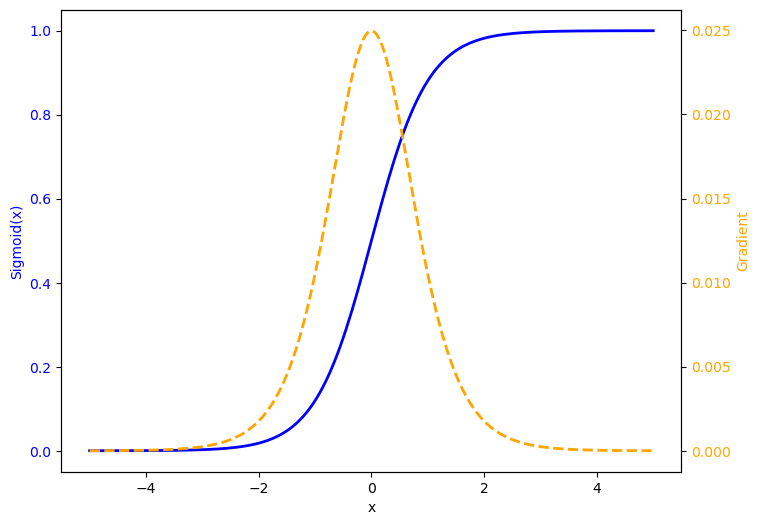

In [4]:
n = 201
x = np.linspace(-5, 5, n)

transformedx = sigmoid(x)
gradientsx = np.gradient(transformedx)

# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the sigmoid function on the left y-axis
ax1.plot(x, transformedx, label='Sigmoid(x)', color='blue', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('Sigmoid(x)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for the gradient
ax2 = ax1.twinx()  # Share the same x-axis
ax2.plot(x, gradientsx, label="Gradient of Sigmoid(x)", color='orange', linestyle='--', linewidth=2)
ax2.set_ylabel('Gradient', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

The value of the derivative is highest at 0. The value of the derivative is low as x goes to infinity and as x goes to negative infinity. Thinking of the sigmoid function as an approximation of an edge in 1-D, we can see that the derivative can tell us where an "edge" is. As in the case above, by finding the location where the gradient is the highest (greatest change in intensity w.r.t. position) we can locate the edge in the image. In the case of this image, the edge is at x = 0.

# Problem 1b.

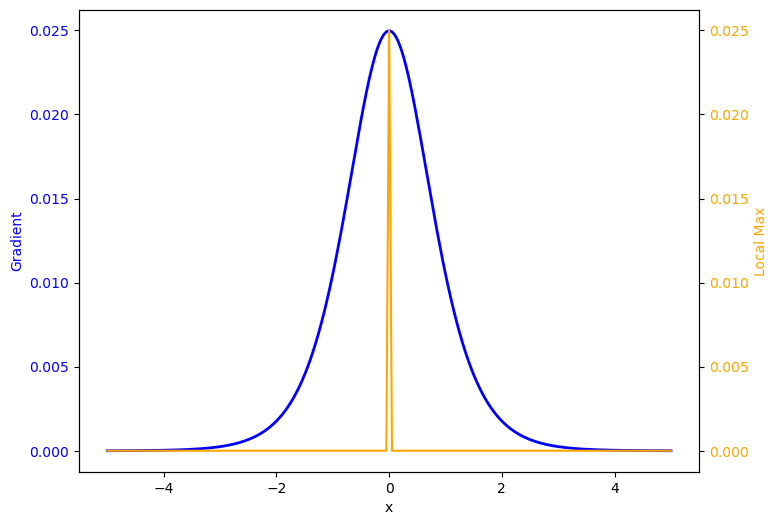

In [5]:
# Locate the maximum of the gradient
length_gradient = len(gradientsx) - 1
max_gradients = []
for i in range(len(gradientsx)):
    if i != 0 and i != length_gradient:
        if gradientsx[i] >= gradientsx[i - 1] and gradientsx[i] >= gradientsx[i + 1]:
            max_gradients.append(gradientsx[i])
        else:
            max_gradients.append(0)

# Plot the derivative and the result of finding local maxes

# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the sigmoid function on the left y-axis
ax1.plot(x, gradientsx, label='Gradient of Sigmoid(x)', color='blue', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('Gradient', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for the gradient
ax2 = ax1.twinx()  # Share the same x-axis
ax2.plot(x, np.pad(max_gradients, 1), label='Local Maxima', color='orange')
ax2.set_ylabel('Local Max', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Problem 1c.

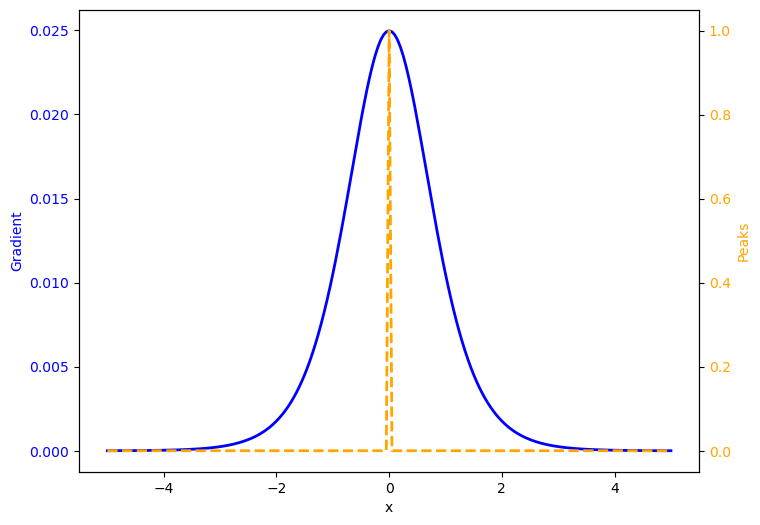

In [6]:
# Verify that the alternative explanation works
xs = np.arange(1, n - 1)
xpeaks = (gradientsx[xs - 1] <= gradientsx[xs]) & (gradientsx[xs] >= gradientsx[xs + 1])

# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the sigmoid function on the left y-axis
ax1.plot(x, gradientsx, label='Gradient Sigmoid(x)', color='blue', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('Gradient', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for the gradient
ax2 = ax1.twinx()  # Share the same x-axis
ax2.plot(x, np.pad(xpeaks, 1), label="Peaks", color='orange', linestyle='--', linewidth=2)
ax2.set_ylabel('Peaks', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Problem 1d.

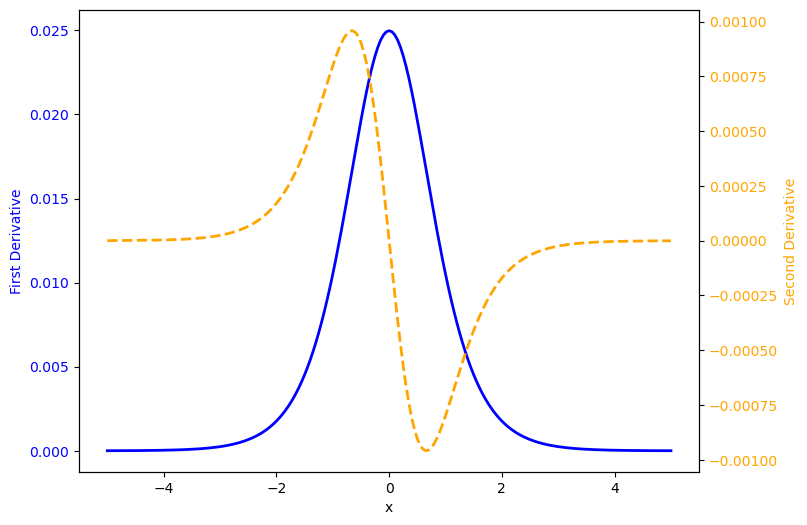

In [7]:
second_der_x = np.gradient(gradientsx)

# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the sigmoid function on the left y-axis
ax1.plot(x, gradientsx, label='First Derivative', color='blue', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('First Derivative', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for the gradient
ax2 = ax1.twinx()  # Share the same x-axis
ax2.plot(x, second_der_x, label="Second Derivative", color='orange', linestyle='--', linewidth=2)
ax2.set_ylabel('Second Derivative', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

The point where the second derivative crosses the y-axis is where the edge is. In other words, the zero crossings of the second derivative or the Laplacian is where the edges in images are. In the case of this 1-D image, it occurs at x = 0. This agrees with what we found earlier where we determined that the edge occurs where the first derivative is the largest, which also occurs at x = 0.

# Problem 1e.

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


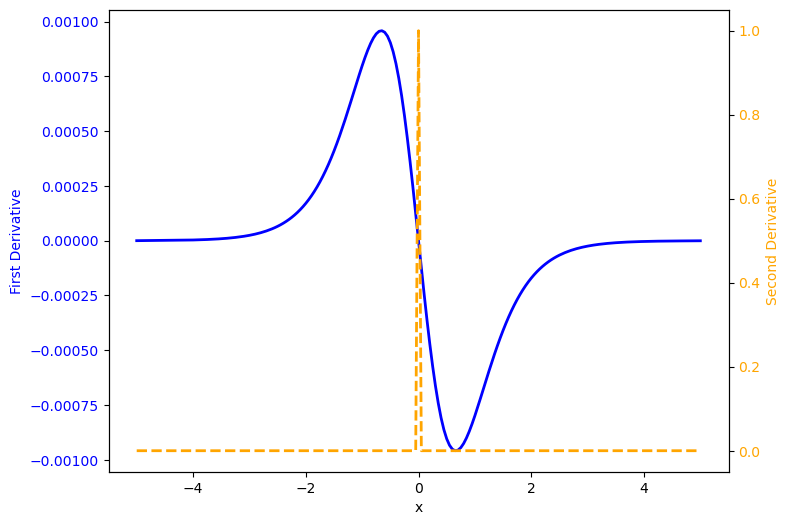

In [8]:
zerocrossings = []
length_second_der_x = len(second_der_x) - 1
for i in range(len(second_der_x)):
    if i != 0 and i != length_second_der_x:
        if ((second_der_x[i - 1] < 0) and (second_der_x[i + 1] > 0)) or ((second_der_x[i - 1] > 0) and (second_der_x[i + 1] < 0)):
            zerocrossings.append(1)
            break
        else:
            zerocrossings.append(0)
zerocrossings += ((len(second_der_x) - 2) - len(zerocrossings)) * [0]
print(zerocrossings)

# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the sigmoid function on the left y-axis
ax1.plot(x, second_der_x, label='First Derivative', color='blue', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('First Derivative', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for the gradient
ax2 = ax1.twinx()  # Share the same x-axis
ax2.plot(x, np.pad(zerocrossings, 1), label="Second Derivative", color='orange', linestyle='--', linewidth=2)
ax2.set_ylabel('Second Derivative', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

To find the point where the edge is like in part b. and part c., I need to find where the zero crossings of the second derivative happen. Because a zero crossings occurs when positive values change to negative values or when negative values change to positive values, I looped through each element in the array and checked whether or not the above conditions were satisfied. If they were, then I appended 1 to the output array and break. If it didn't I appended a 0 to the output array. Then I filled the rest of the array with 0s.

From the plot, it seems that zero crossing is correctly identified as the location where the output array has a value of 1 is at the location 0, which is where the edge is. 

# Problem 2a.

In [9]:
# Sx and Sy
sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

# normalize
sx = sx / 8
sy = sy / 8

In [10]:
# Load in Paulina
paulina = np.array(Image.open("Paolina-2.tiff"))
paulina = paulina.astype('float')/255

Text(0.5, 1.0, 'Sy direction')

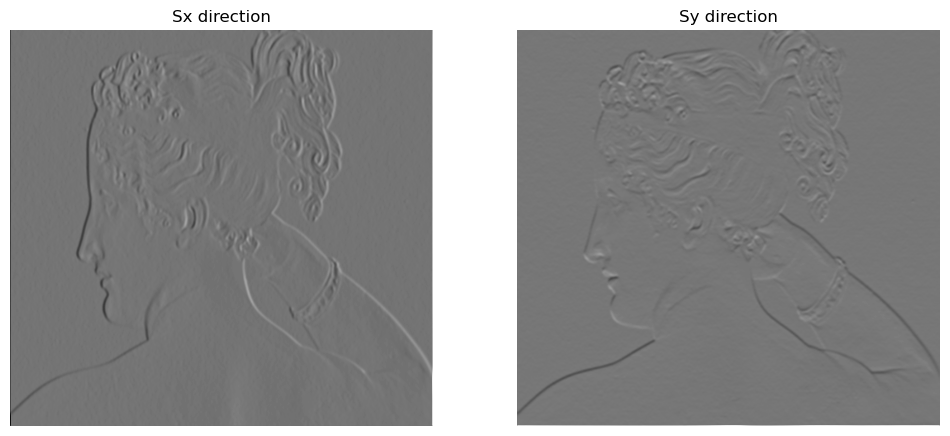

In [11]:
# Convolve paulina with sx and sy
paulina_x = scipy.signal.convolve2d(paulina, sx, mode='same', boundary='fill', fillvalue=0)
paulina_y = scipy.signal.convolve2d(paulina, sy, mode='same', boundary='fill', fillvalue=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()  # Flatten to make it easier to iterate
axes[0].imshow(paulina_x, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Sx direction")
axes[1].imshow(paulina_y, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Sy direction")


The plots convey the result of finding the first derivative in the x direction (left image) and y direction (right image). More specifically, the plots display the areas in the image where the intensity changes are the highest, meaning sharper edges in the two respective directions. These regions are shown as the darker areas in the image (meaning a larger gradient or partial derivative), while areas with smaller gradients are gray in the images. Areas with larger partial derivatives are the edges in the image with respect to the direction. 

In the left image above, the "edges" in the image such as Paulina's face are the edges with respect to the x direction. In contrast, the "edges" in the image on the right are the edges with respect to the y direction, as her shoulders and arms are more defined. 

These results relate to the result from part 1a. because the two images are highlighting the areas in the original image where the difference in intensities is the highest (the edges). However, since the data is now 2-D and not 1-D, we take the derivative in 2 directions, the x and y direction. Therefore, the image on the left is highlighting regions where the difference in intensities in the x-direction is large, while the image on the right is highlighting regions where the difference in intensities in the y-direction is large.

# Problem 2b.

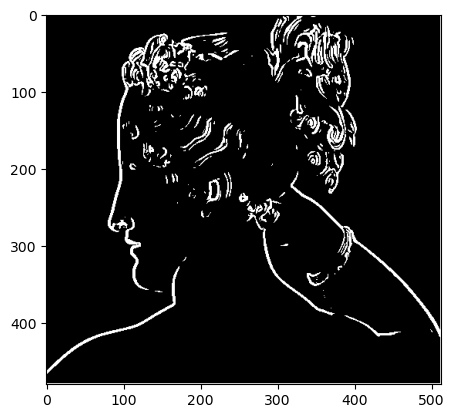

In [12]:
paulina_both = (paulina_x ** 2 + paulina_y ** 2) ** 1/2
paulina_clean = paulina_both > 2 * np.mean(paulina_both)
plt.imshow(paulina_clean, cmap="gray")

# Problem 2c.

In [46]:
m, n = paulina_clean.shape
xs = np.arange(1,n-1)
ys = np.arange(1,m-1)
xpeaks = (paulina_clean[ys][:,xs-1] <= paulina_clean[ys][:,xs]) & (paulina_clean[ys][:,xs] > paulina_clean[ys][:,xs+1])
ypeaks = (paulina_clean[:,xs][ys-1] <= paulina_clean[:,xs][ys]) & (paulina_clean[:,xs][ys] > paulina_clean[:,xs][ys+1])
paulina_post = paulina_clean[ys][:,xs].astype(bool) & ( xpeaks | ypeaks )

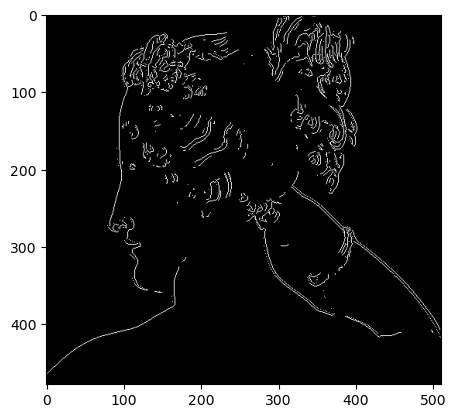

In [48]:
plt.imshow(paulina_post, cmap="gray")

From this image, it seems like the edge map has been "sharpened" in comparison to the cleaned-up magnitude image from part 2b. as the lines are much thinner. In other words, this post-processing step refines the images in the cleaned-up magnitude image. Mathematically, since you are identifying the exact points in both the x and y directions where the pixel intensities to the left and right neighbor are smaller, the resulting image only has the locations in the cleaned-up magnitude image where the gradient of the intensities in the original Paolina image is the largest. 

This is similar to the what was done in part 1b. and part 1c. because in those parts, we took the gradient of the 1-D array and then identified the max of the gradients. In this problem, we previously took the gradient of the 2-D image and then identified the max of the gradient. The key difference is the change in dimensions (from 1-D to 2-D).

This step is necessary to getting an edge map because it is much more accurate then the result from thresholding the intensities in part 2b. By identifying the peaks, we have found the pixels in the image where the Laplacian is 0, corresponding to the edges in the image.

# Problem 2d.

In [53]:
# Load in Paolina 
paulina = np.array(Image.open("Paolina-2.tiff"))
paulina = paulina.astype('float')/255
h, w = paulina.shape  # Height and width of the image

# Generate Gaussian noise
noise = np.random.randn(h, w) * 0.05  # Noise with standard deviation 0.05

# Add noise to the original image
paulina_noise = paulina + noise

Text(0.5, 1.0, 'Sy direction w/noise')

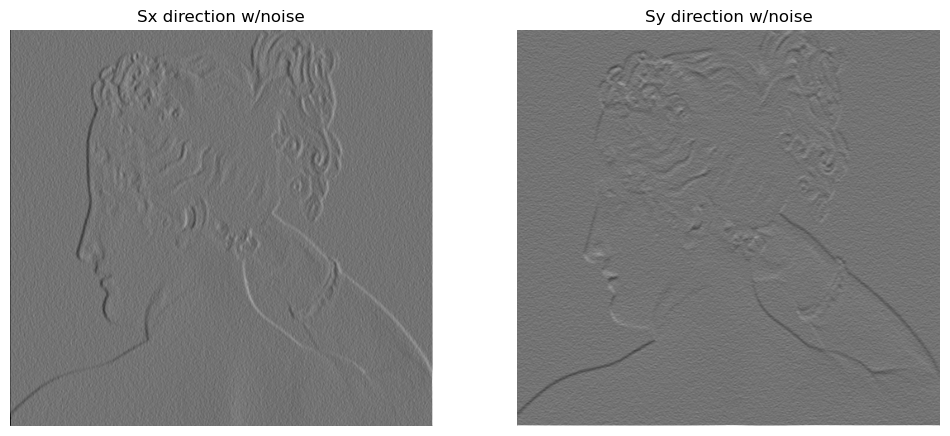

In [55]:
# Convolve noisy paulina with sx and sy
paulina_noise_x = scipy.signal.convolve2d(paulina_noise, sx, mode='same', boundary='fill', fillvalue=0)
paulina_noise_y = scipy.signal.convolve2d(paulina_noise, sy, mode='same', boundary='fill', fillvalue=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()  # Flatten to make it easier to iterate
axes[0].imshow(paulina_noise_x, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Sx direction w/noise")
axes[1].imshow(paulina_noise_y, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Sy direction w/noise")

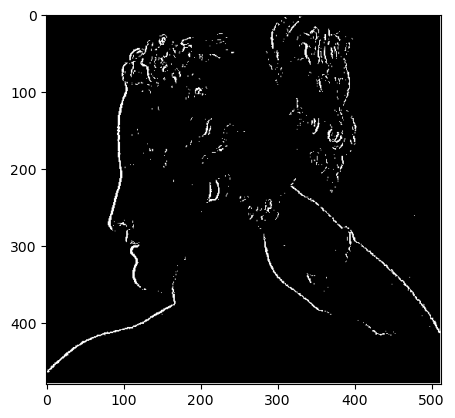

In [ ]:
# Thresholding with a value of 4.2
paulina_noise_both = (paulina_noise_x ** 2 + paulina_noise_y ** 2) ** 1/2
paulina_noise_clean = paulina_noise_both > 4.2 * np.mean(paulina_noise_both)
plt.imshow(paulina_noise_clean, cmap="gray")

In [66]:
m, n = paulina_noise_clean.shape
xs = np.arange(1,n-1)
ys = np.arange(1,m-1)
xpeaks = (paulina_noise_clean[ys][:,xs-1] <= paulina_noise_clean[ys][:,xs]) & (paulina_noise_clean[ys][:,xs] > paulina_noise_clean[ys][:,xs+1])
ypeaks = (paulina_noise_clean[:,xs][ys-1] <= paulina_noise_clean[:,xs][ys]) & (paulina_noise_clean[:,xs][ys] > paulina_noise_clean[:,xs][ys+1])
paulina_noise_post = paulina_noise_clean[ys][:,xs].astype(bool) & ( xpeaks | ypeaks )

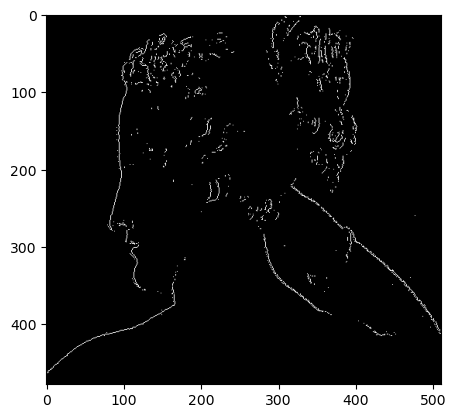

In [67]:
plt.imshow(paulina_noise_post, cmap="gray")

# Problem 4e.

In [ ]:
# Blur with sigma = 1
paulina_blur = scipy.ndimage.gaussian_filter(paulina_noise, sigma = 1)

Text(0.5, 1.0, 'Sy direction w/noise and blur')

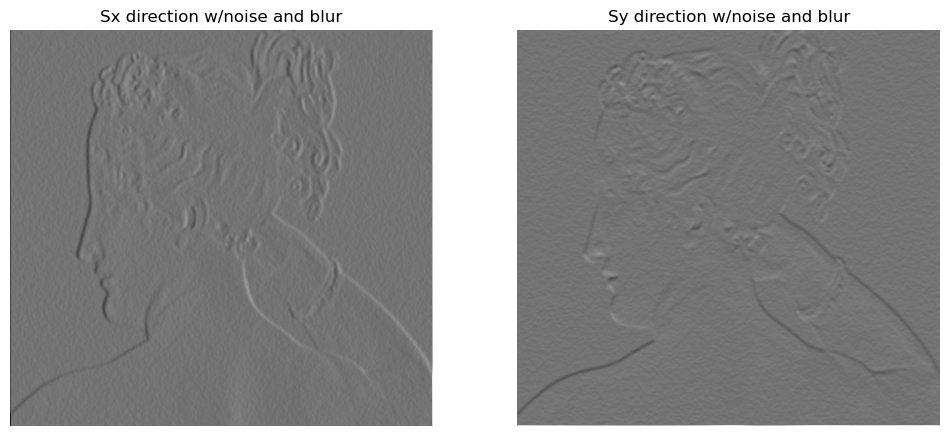

In [72]:
# Convolve noisy paulina with sx and sy
paulina_blur_x = scipy.signal.convolve2d(paulina_blur, sx, mode='same', boundary='fill', fillvalue=0)
paulina_blur_y = scipy.signal.convolve2d(paulina_blur, sy, mode='same', boundary='fill', fillvalue=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()  # Flatten to make it easier to iterate
axes[0].imshow(paulina_blur_x, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Sx direction w/noise and blur")
axes[1].imshow(paulina_blur_y, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Sy direction w/noise and blur")

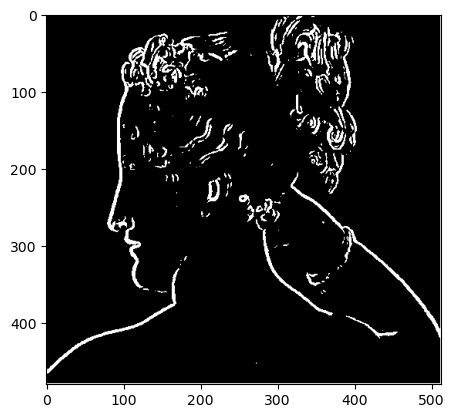

In [ ]:
# Thresholding with a value of 1.8
paulina_blur_both = (paulina_blur_x ** 2 + paulina_blur_y ** 2) ** 1/2
paulina_blur_clean = paulina_blur_both > 1.8 * np.mean(paulina_blur_both)
plt.imshow(paulina_blur_clean, cmap="gray")

In [77]:
m, n = paulina_blur_clean.shape
xs = np.arange(1,n-1)
ys = np.arange(1,m-1)
xpeaks = (paulina_blur_clean[ys][:,xs-1] <= paulina_blur_clean[ys][:,xs]) & (paulina_blur_clean[ys][:,xs] > paulina_blur_clean[ys][:,xs+1])
ypeaks = (paulina_blur_clean[:,xs][ys-1] <= paulina_blur_clean[:,xs][ys]) & (paulina_blur_clean[:,xs][ys] > paulina_blur_clean[:,xs][ys+1])
paulina_blur_post = paulina_blur_clean[ys][:,xs].astype(bool) & ( xpeaks | ypeaks )

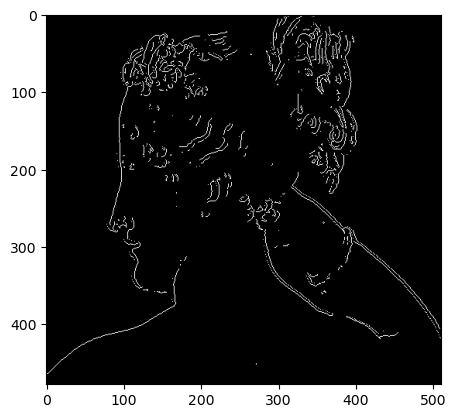

In [78]:
plt.imshow(paulina_blur_post, cmap="gray")

The preprocessing with the blur improves the result a lot. Before applying the Gaussian blur, it was very difficult to achieve a representative edge map as seen in part 2c. Because of the added noise, increasing the threshold lead to filtering out too much information, leading to a loss of edges. Further, decreasing the threshold lead to too much information getting kept, which lead to extra noise in the edge map. When applying the preprocessing step with a blur of sigma = 1 and a threshold of 1.8, I am able to achieve an edge map that resembles the edge map constructed in the original image without noise. 

# Problem 1f.

Based on the results from part 1e., where we calculated the second derivative and identified the locations where second derivative was 0 (zero-crossings), the same intuition can be applied to 2-D images. In essence, because the Laplacian is an extension of the second derivative to 2-D, we can take the Laplacian of the image and identify the locations in the image where the Laplacian equals 0. By composing the Gaussian with the Laplacian, we can blur the image to remove noise in the input. Then, we find the Laplacian of the image to identify the locations where it is equal to zero.

# Problem 3a.

In [149]:
def gaborfilter(theta, wavelength, phase, sigma, aspect, ksize=None):

    """
    GB = GABORFILTER(THETA, WAVELENGTH, PHASE, SIGMA, ASPECT, KSIZE)
    creates a Gabor filter GB with orientation THETA (in radians),
    wavelength WAVELENGTH (in pixels), phase offset PHASE (in radians),
    envelope standard deviation SIGMA, aspect ratio ASPECT, and dimensions
    KSIZE x KSIZE. KSIZE is an optional parameter, and if omitted default
    dimensions are selected.
    """

    if ksize is None:
        ksize = 8*sigma*aspect


    if type(ksize) == int or len(ksize) == 1:
        ksize = [ksize, ksize]


    xmax = np.floor(ksize[1]/2.)
    xmin = -xmax
    ymax = np.floor(ksize[0]/2.)
    ymin = -ymax

    xs, ys = np.meshgrid(np.arange(xmin,xmax+1), np.arange(ymax,ymin-1,-1))

    # Your code here
    transformed_x = []
    transformed_y = []
    for i in range(len(xs)):
        tempx = []
        tempy = []
        for j in range(len(xs[0])):
            x_prime = xs[i][j] * math.cos(theta) + ys[i][j] * math.sin(theta)
            y_prime = -xs[i][j] * math.sin(theta) + ys[i][j] * math.cos(theta)
            tempx.append(x_prime)
            tempy.append(y_prime)
        transformed_x.append(tempx)
        transformed_y.append(tempy)
    transformed_x = np.array(transformed_x)
    transformed_y = np.array(transformed_y)

    gabor = []
    for i in range(len(transformed_x)):
        temp = []
        for j in range(len(transformed_x[0])):
            base = math.sin(((2 * math.pi) / wavelength) * transformed_y[i][j] + phase)
            exp = -(((transformed_x[i][j] ** 2) / (aspect ** 2)) + (transformed_y[i][j] ** 2)) / (2 * sigma ** 2)
            g = math.sin(((2 * math.pi) / wavelength) * transformed_y[i][j] + phase) * math.exp(exp)
            temp.append(g)
        gabor.append(temp)
    gabor = np.array(gabor)
    norm_sum_zero = gabor - np.mean(gabor)
    sum_squares = np.sum(norm_sum_zero ** 2) 
    norm_sum_squares = norm_sum_zero / np.sqrt(sum_squares)
    return norm_sum_squares


    


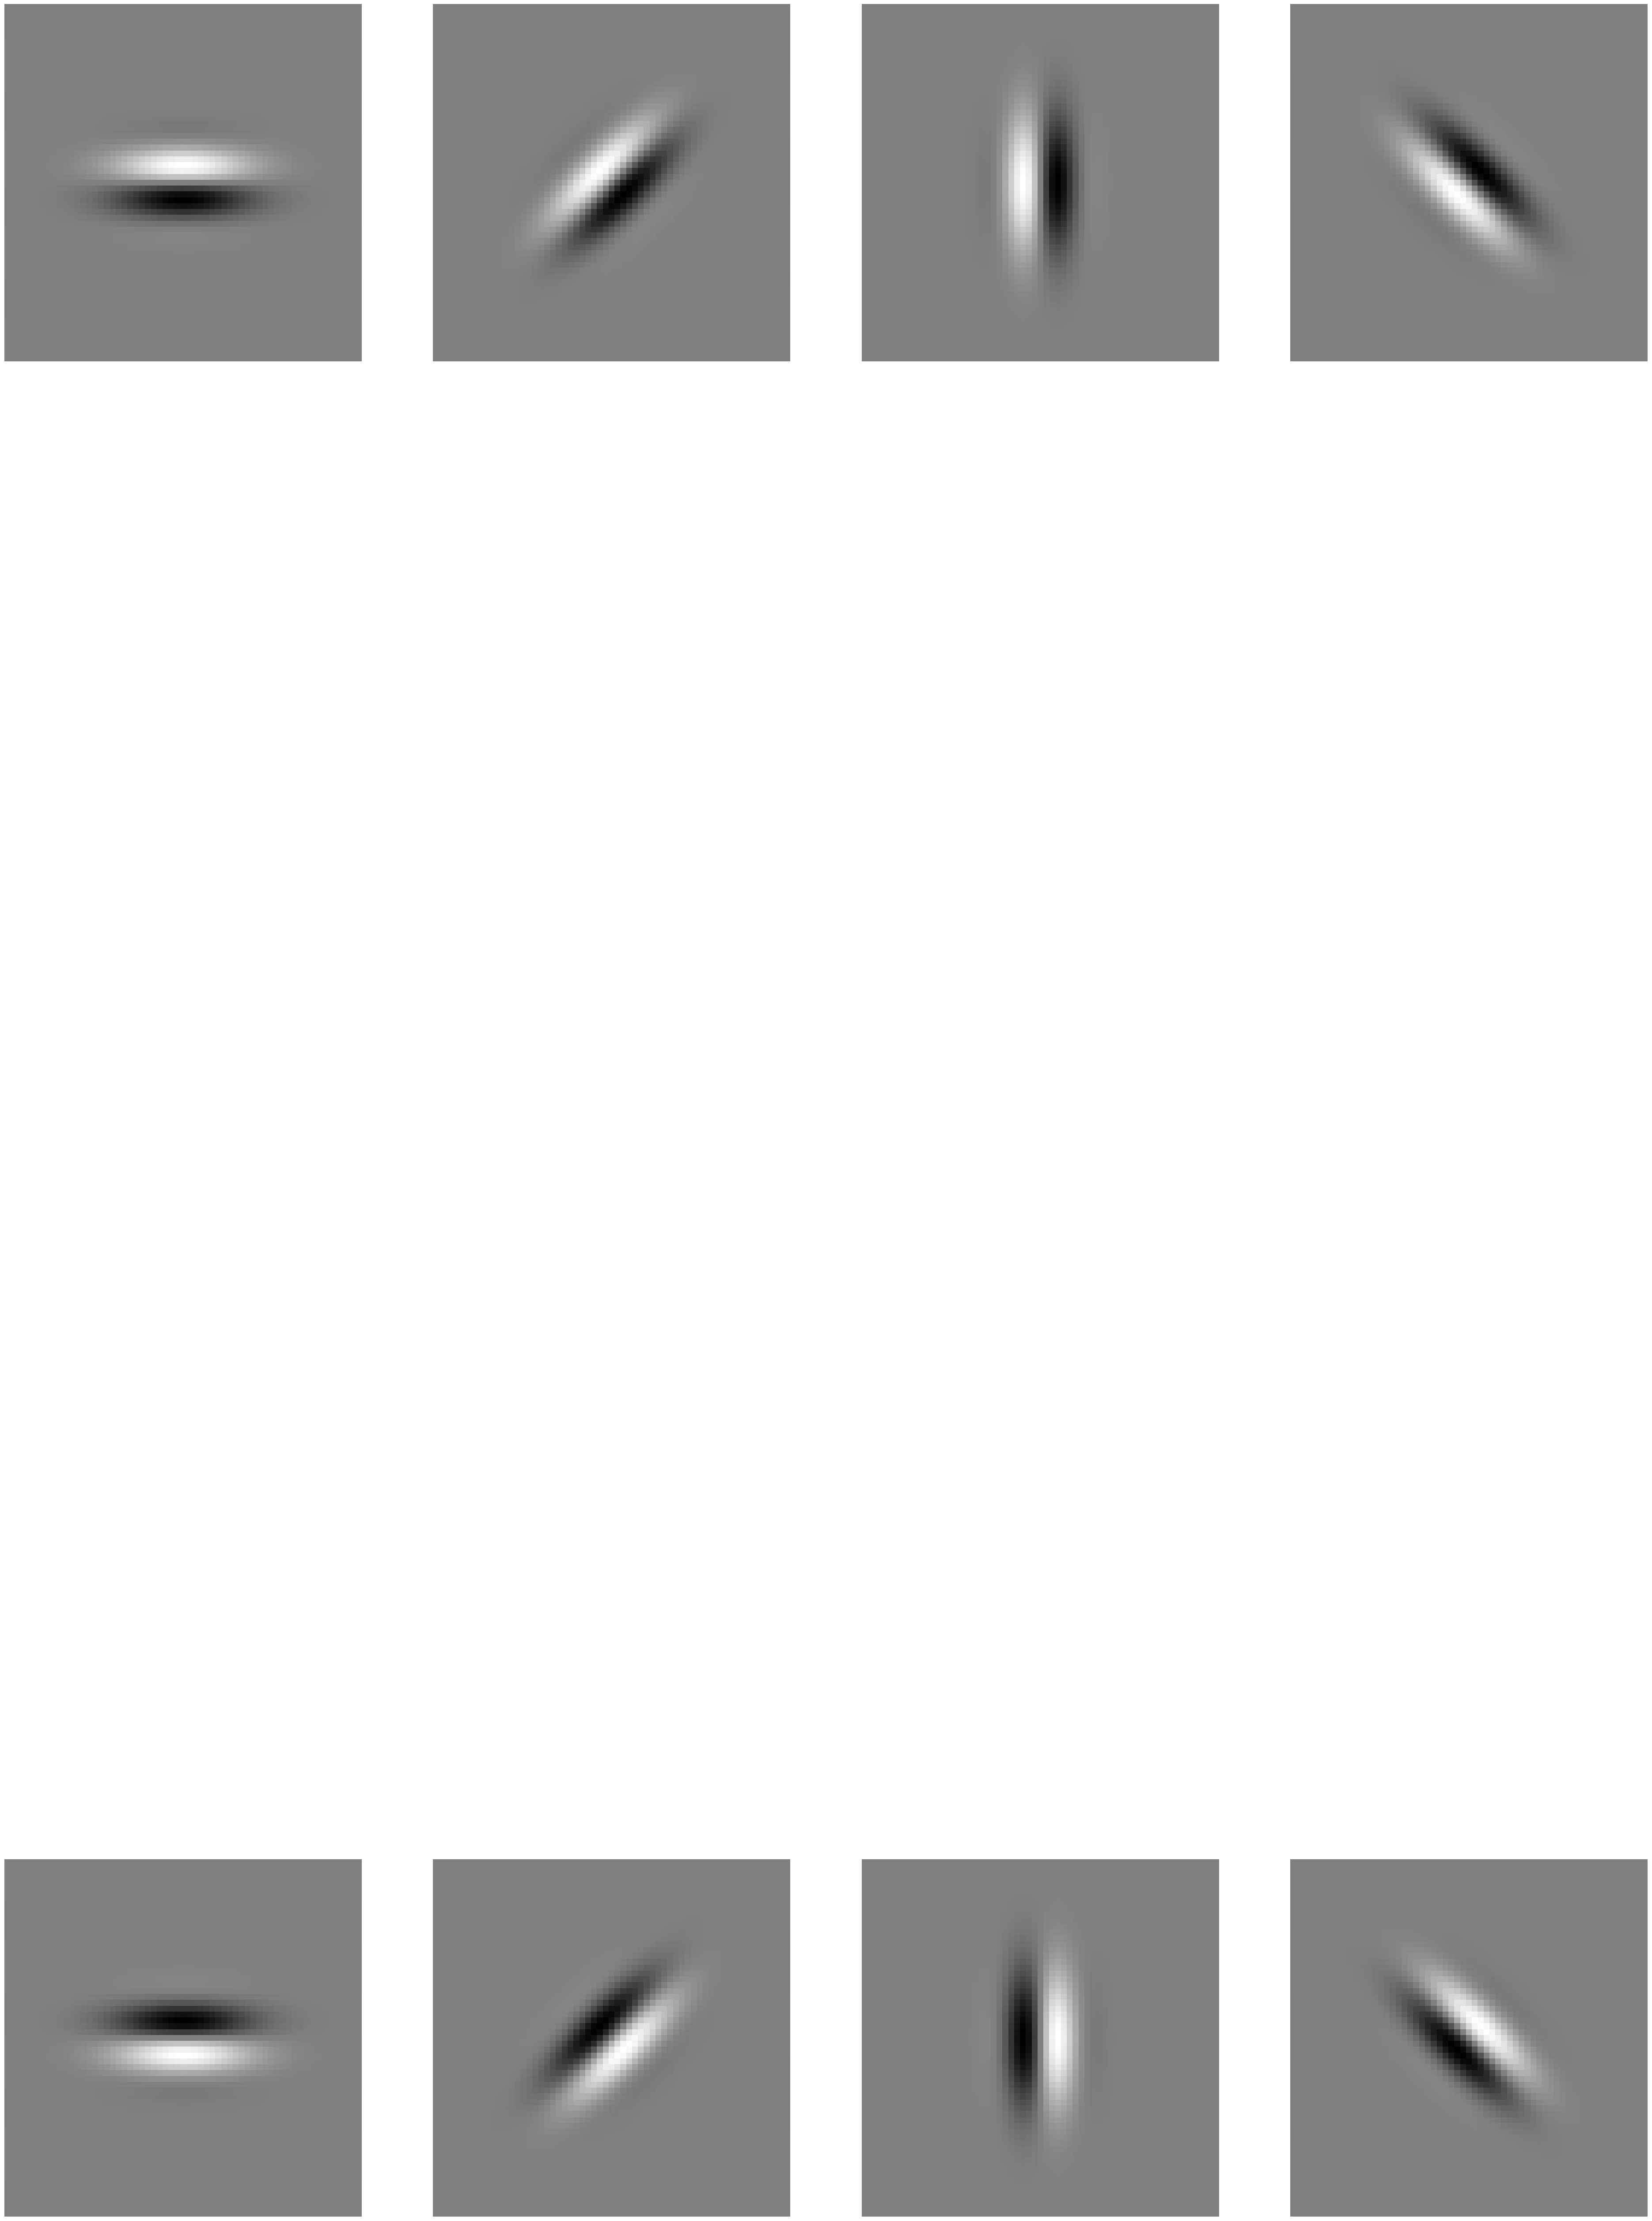

In [95]:
# Edge Enhancing Filters
fig, axes = plt.subplots(2, 4, figsize=(48, 100))
axes = axes.flatten()  # Flatten to make it easier to iterate
for i in range(0, 8):
    axes[i].imshow(gaborfilter(i * math.pi / 4, 16, 0, 4, 2, ksize=60), cmap='gray')
    axes[i].axis('off')

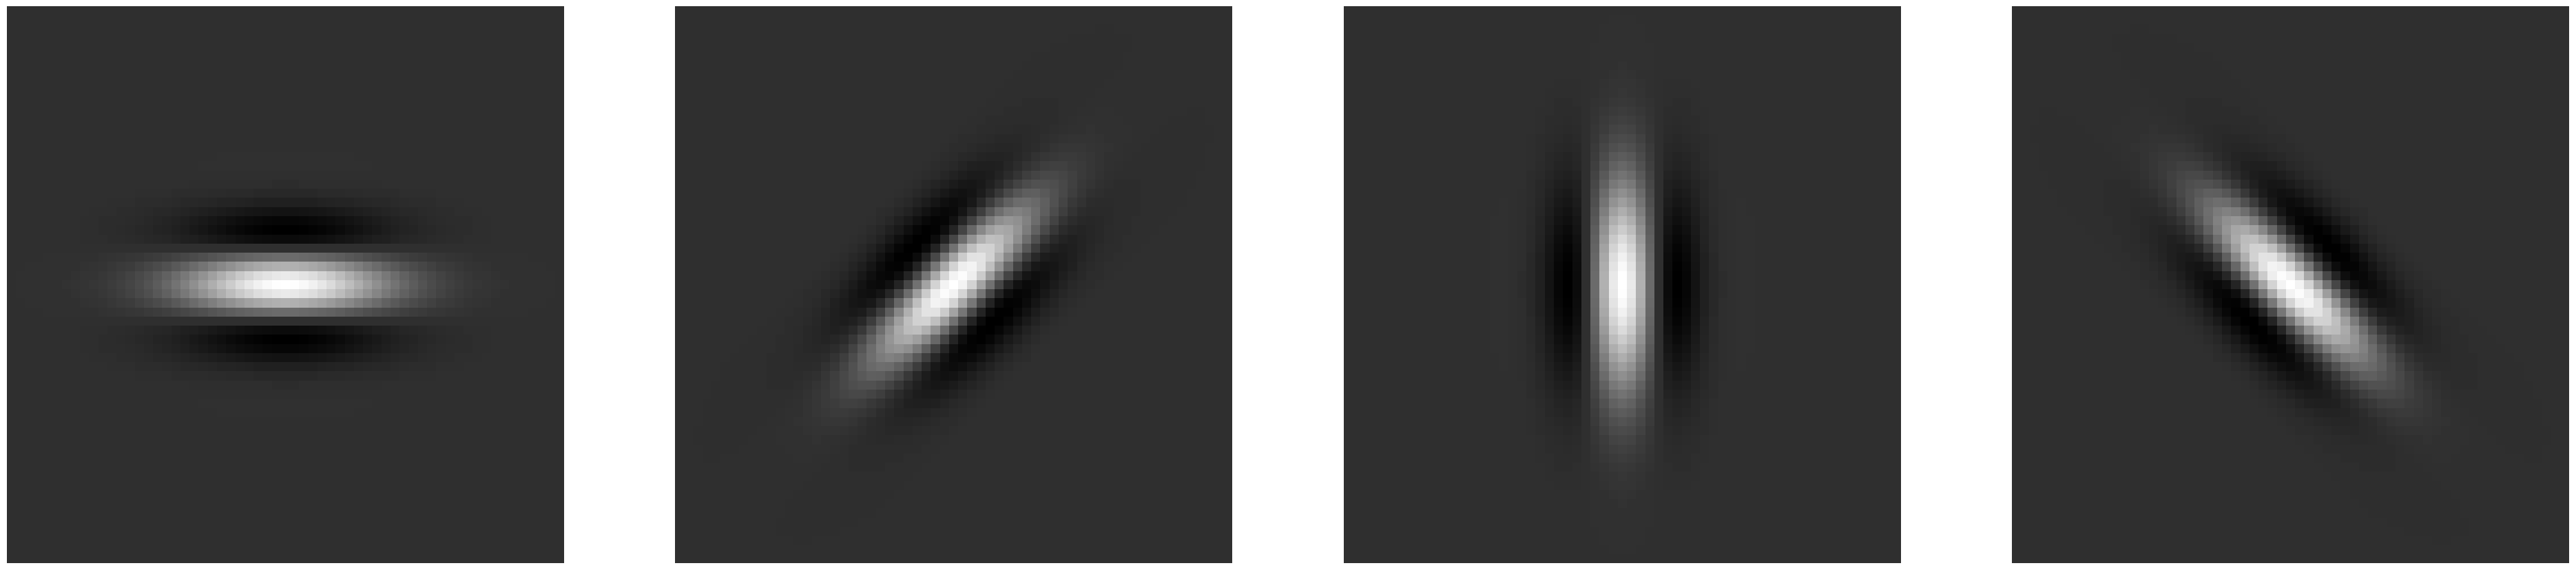

In [103]:
# Bright Enhancing Filters
fig, axes = plt.subplots(1, 4, figsize=(48, 100))
axes = axes.flatten()  # Flatten to make it easier to iterate
for i in range(0, 4):
    axes[i].imshow(gaborfilter(i * math.pi / 4, 16, math.pi/2, 4, 2, ksize=60), cmap='gray')
    axes[i].axis('off')

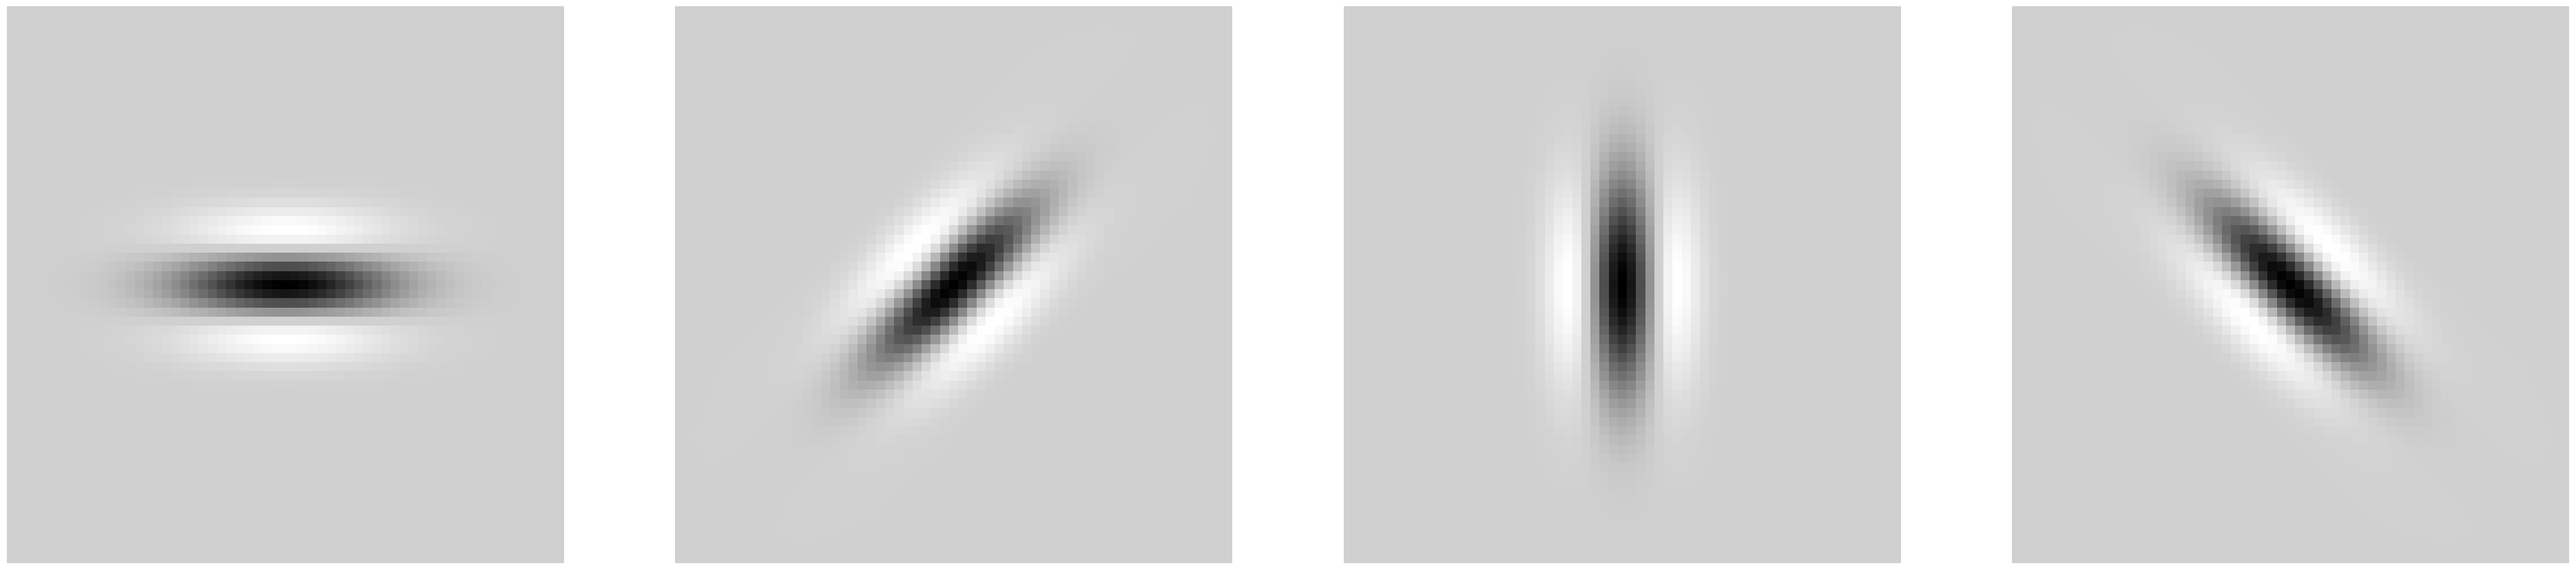

In [154]:
# Dark Enhancing Filters
fig, axes = plt.subplots(1, 4, figsize=(48, 100))
axes = axes.flatten()  # Flatten to make it easier to iterate
for i in range(0, 4):
    axes[i].imshow(gaborfilter(i * math.pi / 4, 16, 3 * math.pi/2, 4, 2, ksize=60), cmap='gray')
    axes[i].axis('off')

To choose the wavelength and the standard deviation, I tried out different combinations of wavelengths and standard deviations where the wavelength is 4 * the standard deviation as suggested in the instructions. From these experiments, it seemed that as the standard deviation (and as a result, the wavelength) decreased, it became harder to distinguish between the dark and bright lines as they became more pixelated and mixed. In contrast, increasing the standard deviation (and as a result the wavelength) resulted in filters where the black line and white line were too large and not refined. Therefore, the I chose the 16-4 combination of wavelength and standard deviation values as it seemed like a perfect balance between the size of the edge and clarity of the shape of the filter.

# Problem 3b.

Text(0.5, 1.0, 'Regular Loki')

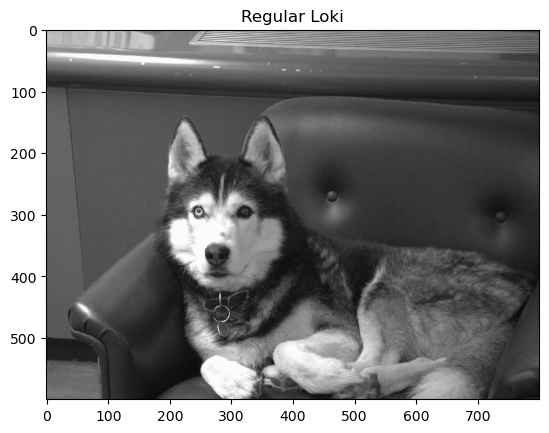

In [144]:
loki = np.array(Image.open("Loki-1.tiff"))
loki = loki.astype('float')/255
plt.imshow(loki, cmap="gray")
plt.title("Regular Loki")

In [142]:
edge_enhancement = gaborfilter(0 * math.pi / 4, 4, 0, 1, 2, ksize=60)
bright_enhancement = gaborfilter(0 * math.pi / 4, 4, math.pi/2, 1, 2, ksize=60)
dark_enhancement = gaborfilter(0 * math.pi / 4, 4, 3 * math.pi/2, 1, 2, ksize=60)

Text(0.5, 1.0, 'Edge Enhanced Loki')

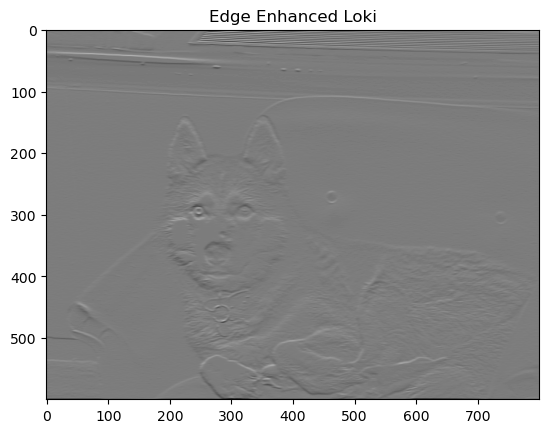

In [145]:
edge_enhancement_loki = scipy.signal.convolve2d(loki, edge_enhancement, mode='same', boundary='fill', fillvalue=0)
plt.imshow(edge_enhancement_loki, cmap="gray")
plt.title("Edge Enhanced Loki")

Text(0.5, 1.0, 'Bright enhanced Loki')

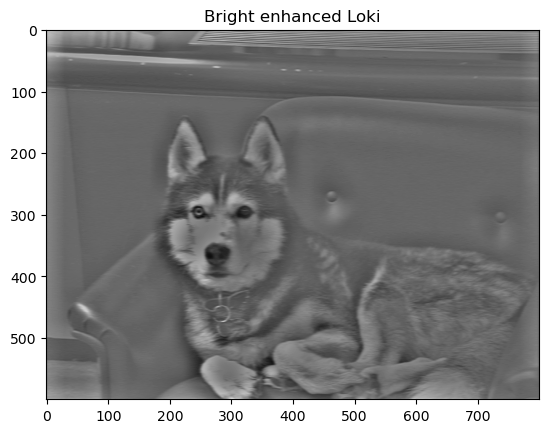

In [146]:
bright_enhancement_loki = scipy.signal.convolve2d(loki, bright_enhancement, mode='same', boundary='fill', fillvalue=0)
plt.imshow(bright_enhancement_loki, cmap="gray")
plt.title("Bright enhanced Loki")

Text(0.5, 1.0, 'Dark Enhanced Loki')

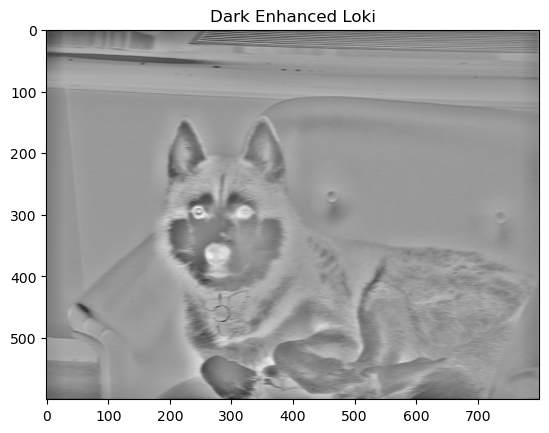

In [147]:
dark_enhancement_loki = scipy.signal.convolve2d(loki, dark_enhancement, mode='same', boundary='fill', fillvalue=0)
plt.imshow(dark_enhancement_loki, cmap="gray")
plt.title("Dark Enhanced Loki")

Text(0.5, 1.0, 'Regular Loki')

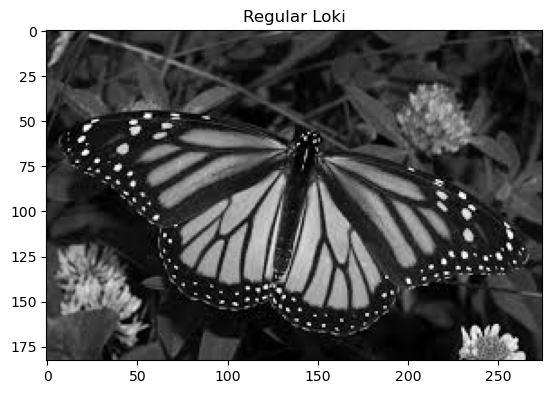

In [159]:
butterfly = np.array(Image.open("butterfly.tiff"))
butterfly = butterfly.astype('float')/255
butterfly = np.dot(butterfly[...,:3], [0.2989, 0.5870, 0.1140])
plt.imshow(butterfly, cmap="gray")
plt.title("Regular Loki")

Text(0.5, 1.0, 'Edge Enhanced Butterfly')

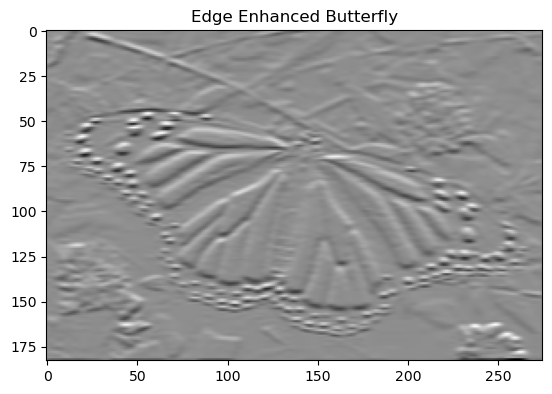

In [160]:
edge_enhancement_butterfly = scipy.signal.convolve2d(butterfly, edge_enhancement, mode='same', boundary='fill', fillvalue=0)
plt.imshow(edge_enhancement_butterfly, cmap="gray")
plt.title("Edge Enhanced Butterfly")

Text(0.5, 1.0, 'Bright enhanced Butterfly')

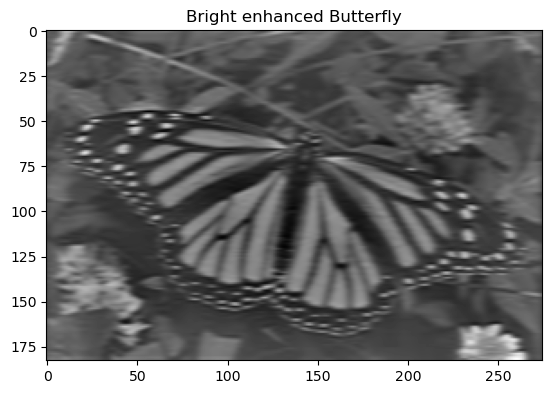

In [ ]:
bright_enhancement_butterfly = scipy.signal.convolve2d(butterfly, bright_enhancement, mode='same', boundary='fill', fillvalue=0)
plt.imshow(bright_enhancement_butterfly, cmap="gray")
plt.title("Bright enhanced Butterfly")

Text(0.5, 1.0, 'Dark Enhanced Loki')

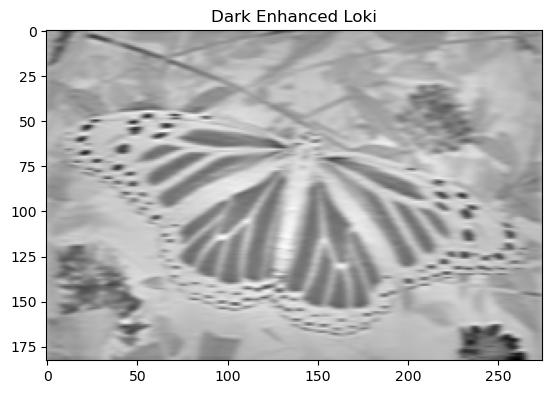

In [162]:
dark_enhancement_butterfly = scipy.signal.convolve2d(butterfly, dark_enhancement, mode='same', boundary='fill', fillvalue=0)
plt.imshow(dark_enhancement_butterfly, cmap="gray")
plt.title("Dark Enhanced Loki")

In this problem, I compared the edge enhancer, bright line enhancer, and dark line enhancer for Gabor filter with an orientation of 0 for two images: Loki and a butterfly. From the above images, the edge enhancement Gabor filter highlights the edge in the image by drawing outlines around the edges in the original image and making all other values grayscale. The bright line enhancer maintains the general relationship in images by brightening pixels that are lighter and darkening pixels that are not. In contrast, the dark enhancement filter switches the intensities by highlighting regions in the original image with darker intensities and giving dark intensities to regions in the original image with brighter intensities.

# Problem 4c.

Gabor filters are similar to our receptive fields in our visual cortex because of its selectivity to different orientations of edges. In our visual cortex, we have a columnar architecture, where columns are representative of receptive fields selected to different orientations. Each receptive fields is a combination of ON and OFF retinal ganglion cells positioned in different ways to only fire if the input is representative of the orientation that the receptive field is selective for. Likewise, we have many different orientations of each Gabor filter as well. For example, for the task of edge enhancement, there are 8 different orientations for the filters. Furthermore, similar to the receptive fields in the cortex, these Gabor filters are selective to edges that match well with the orientation of the filter.

The biological advantage of having different receptive fields tuned to different orientaitons is that the brain can build up more complex cells with receptive fields more advanced than a line pointing in a certain direction. In comparison to having a single type of receptive field, the brain can now tune for different combinations of these receptive fields allowing for organisms to understand complex patterns and objects. Computationally, there is an advantage of having the Gabor filters having different orientations because we can build up different combinations of these filters to specifically locate different types of edges in an image in comparison to an "all purpose" edge filter.

# Problem 4d.

Given that a Gabor filter is the pointwise product of a Gaussian function and a sinusoid in the space domain, we can apply what we know about transforming between the space frequency domains to determine what the frequency domain representation of a Gabor filter is. Because we know that a product in one domain is a convolution in another domain, since the Gabor is a product of a Gaussian (G) and a sinusoid (s) in the space domain, it is equivalently a the FT(s) convolved with the FT(G). Given that the FT of a Gaussian is a Gaussian and the FT of a sinusoid is a pair of delta functions, then the delta function convolved the Gaussian would result in a pair of Gaussians in the frequency domain.

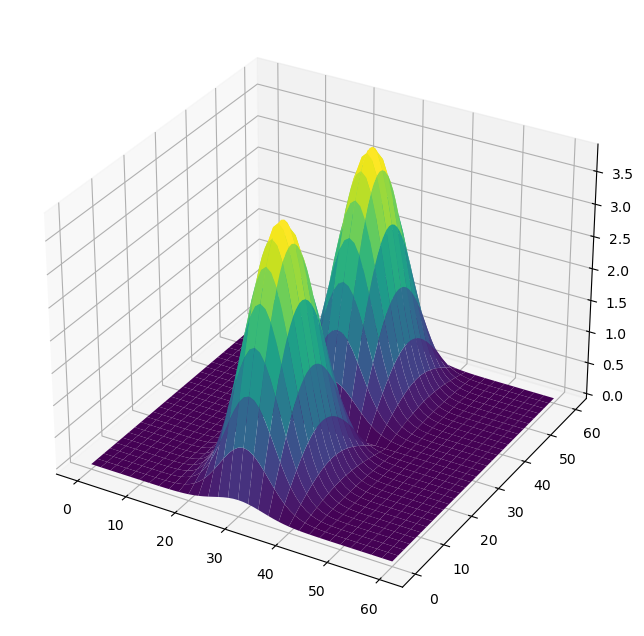

In [157]:
# Confirmation of hypothesis above
gabor_ft = np.fft.fft2(edge_enhancement)
gabor_ft = np.abs(np.fft.fftshift(gabor_ft))

x = np.arange(gabor_ft.shape[1])
y = np.arange(gabor_ft.shape[0])
x, y = np.meshgrid(x, y)

# Plotting the 3D surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(x, y, gabor_ft,cmap='viridis')

As hypothesized, the frequency domain representation of the Gabor filter is a pair of Gaussians.